# Péndulos acoplados

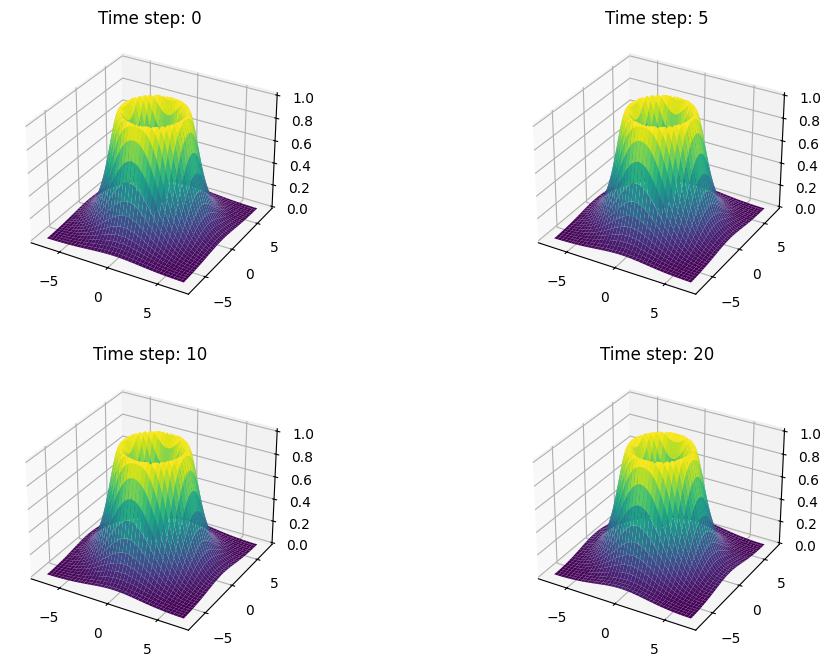

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parámetros
N = 201
L = 14.0
dx = L / N
dt = dx / np.sqrt(2) # Condición de estabilidad tipo CFL
step_to_plot = [0, 5, 10, 20] # Tiempos a graficar

# Grilla
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

# Variables
u = np.zeros((N, N)) # Desplazamiento en el tiempo actual
u_prev = np.zeros((N, N)) # Desplazamiento en el tiempo anterior
u_next = np.zeros((N, N)) # Desplazamiento en el próximo tiempo

# Condición inicial: ring soliton
R = np.sqrt(X**2 + Y**2)
u = 4*np.arctan(np.exp(3 - R))
u_prev = np.copy(u)

# Función Laplaciano
def laplacian(u):
    return (
        np.roll(u, 1, axis=0) + 
        np.roll(u, -1, axis=0) +
        np.roll(u, 1, axis=1) +
        np.roll(u, -1, axis=1)
        - 4*u
    ) / dx**2

# Evolución temporal
snapshots = []

for t in range(max(step_to_plot)+1):
    # Guardar snapshots
    if t in step_to_plot:
        snapshots.append(np.sin(u/2))

    # Esquema Leapfrog
    u_next = (
        2*u - u_prev
        + dt**2 * (laplacian(u) - np.sin(u))
    )

    # Condición de frontera simples (Neumann)
    u_next[0,:] = u_next[1,:]
    u_next[-1,:] = u_next[-2,:]
    u_next[:,0] = u_next[:,1]
    u_next[:,-1] = u_next[:,-2]

    # Avanzar
    u_prev = np.copy(u)
    u = np.copy(u_next)

# Graficar 3D resultados
fig = plt.figure(figsize=(12, 8))
for i, snapshot in enumerate(snapshots):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.plot_surface(X, Y, snapshot, cmap='viridis')
    ax.set_title(f'Time step: {step_to_plot[i]}')
plt.show()

# Ecuación de continuidad (Hidrodinámica)

## Principio de conservación de la masa

$$\frac{\partial \rho}{\partial t} + \nabla \cdot \bf{j} = 0$$

$$ \bf{j} = \rho \bf{v} $$

Interpretación de densidad está relacionado con el flujo de masa.

## Ecuación de Navier-Stokes

Describe el movimiento de fluidos viscosos:

$$ \frac{D \bf{v}}{Dt} = \nu \nabla^2 \bf{v} - \frac{1}{\rho} \nabla p $$

Donde $\nu$ es la viscosidad cinemática, $p$ es la presión, y $\rho$ es la densidad del fluido.

### Derivada Hidrodinámica

$$ \frac{D \bf{v}}{Dt} = \frac{\partial \bf{v}}{\partial t} + (\bf{v} \cdot \nabla) \bf{v} $$

Significado

- Cambio temporal local
- Transporte por el flujo (no linealidad)

### Aproximaciones

Suponemos: 
- Flujo estacionario ($\frac{\partial \bf{v}}{\partial t} = 0$)
- Flujo incompresible ($\nabla \cdot \bf{v} = 0$)

$$ \nabla \cdot \bf{v} = 0 $$

$$ (\bf{v} \cdot \nabla) \bf{v} = \nu \nabla^2 \bf{v} - \frac{1}{\rho} \nabla p $$

### Caso 2D

Sistema en dos dimensiones:

$$ \frac{\partial v_x}{\partial x} + \frac{\partial v_y}{\partial y} = 0 $$

$$ \nu \nabla^2 v_x = v_x \frac{\partial v_x}{\partial x} + v_y \frac{\partial v_x}{\partial y} + \frac{1}{\rho} \frac{\partial p}{\partial x} $$

$$ \nu \nabla^2 v_y = v_x \frac{\partial v_y}{\partial x} + v_y \frac{\partial v_y}{\partial y} + \frac{1}{\rho} \frac{\partial p}{\partial y} $$

### Método Numérico

Se usa sobrerrelajación sucesiva (SOR)
- Discretización del espacio en una malla
- Iteración para resolver las ecuaciones de Navier-Stokes
- Condiciones de frontera: no deslizante (velocidad cero en las paredes)

Algoritmo SOR: 

$$ v_{i,j}^{(k+1)} = (1-\omega) v_{i,j}^{(k)} + \frac{\omega}{4} \left( v_{i+1,j}^{(k)} + v_{i-1,j}^{(k+1)} + v_{i,j+1}^{(k)} + v_{i,j-1}^{(k+1)} \right) $$

Condiciones de frontera para la función de corriente u: 
- Entrada: u = V_0y
- ... 

Término asociado a la vorticidad

para la vorticidad w: 
- Entrada y salida: w = 0
- Superficie: w = 0
- Viga: (Completar luego)

Convergió en 2124 iteraciones, error=9.97e-07


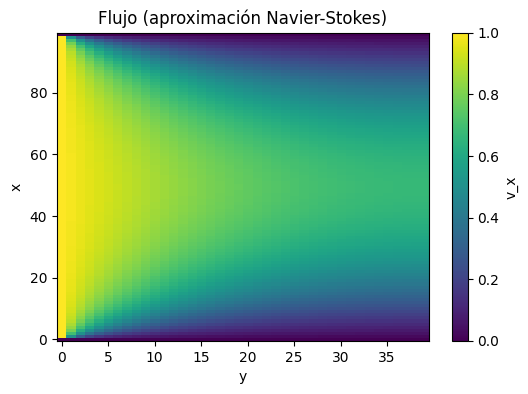

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
Nx, Ny = 100, 40
h = 1.0
omega = 1.5  # 1 < omega < 2 para SOR
max_iter = 5000
tol = 1e-6

# Campos
vx = np.zeros((Nx, Ny))
P = np.zeros((Nx, Ny))

# Gradiente de presión (ejemplo)
dPdx = (np.roll(P, -1, axis=0) - np.roll(P, 1, axis=0)) / (2 * h)

for it in range(max_iter):
    vx_old = vx.copy()

    # Fronteras
    vx[:, 0] = 1.0       # Entrada (izquierda)
    vx[:, -1] = vx[:, -2]  # Salida: derivada normal ~ 0
    vx[0, :] = 0.0       # Pared superior
    vx[-1, :] = 0.0      # Pared inferior

    # SOR para: ∇^2 vx = dPdx
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            vx_gs = 0.25 * (
                vx[i + 1, j] + vx[i - 1, j] + vx[i, j + 1] + vx[i, j - 1]
                - h**2 * dPdx[i, j]
            )
            vx[i, j] = (1 - omega) * vx[i, j] + omega * vx_gs

    # Criterio de convergencia
    err = np.max(np.abs(vx - vx_old))
    if err < tol:
        print(f"Convergió en {it + 1} iteraciones, error={err:.2e}")
        break
else:
    print(f"No convergió en {max_iter} iteraciones, error final={err:.2e}")

# Visualización
plt.figure(figsize=(6, 4))
plt.imshow(vx, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='v_x')
plt.title('Flujo (aproximación Navier-Stokes)')
plt.xlabel('y')
plt.ylabel('x')
plt.show()